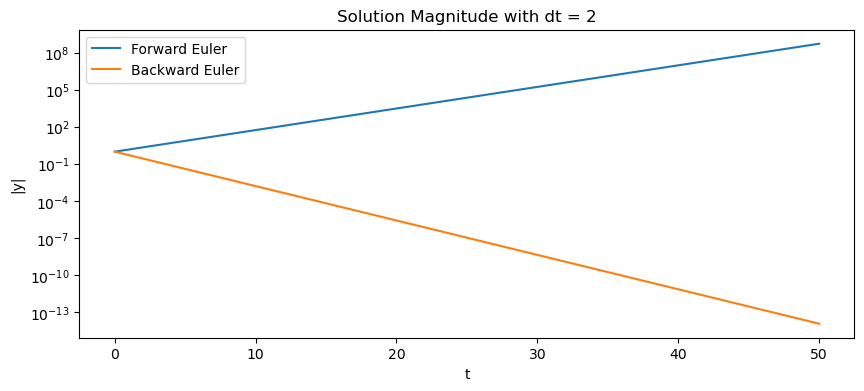

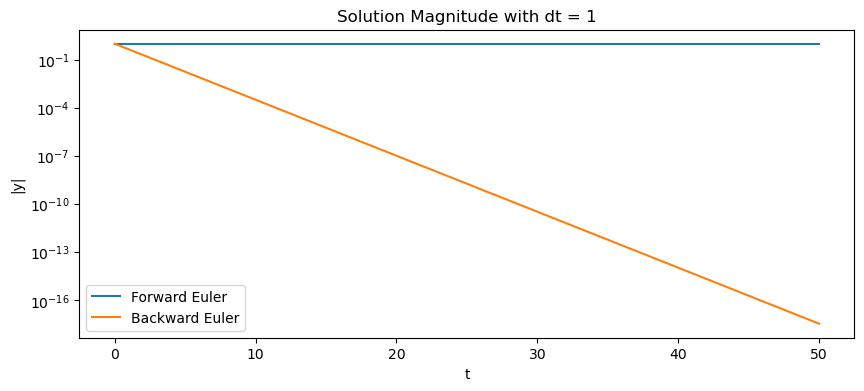

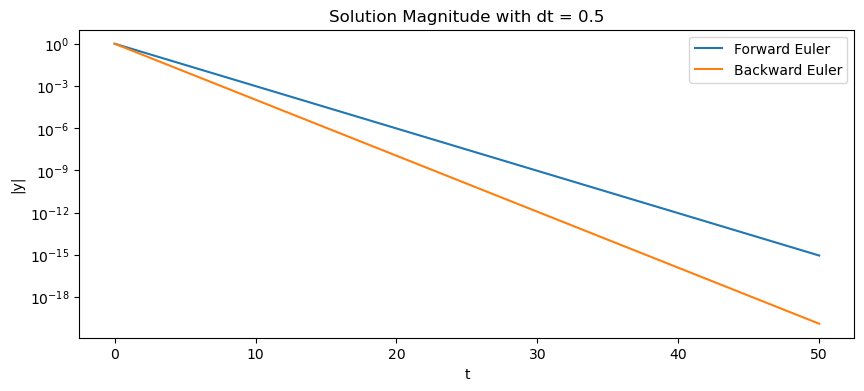

In [2]:
import numpy as np
import matplotlib.pyplot as plt

lmbda = -1 + 1j
y0 = 1.0

def simulate_euler(dt, t_end=50):
    t = np.arange(0, t_end + dt, dt)
    n_steps = len(t) - 1

    yf = np.zeros(len(t), dtype=complex)
    yf[0] = y0
    for n in range(n_steps):
        yf[n+1] = yf[n] + dt * (lmbda * yf[n])

    yb = np.zeros(len(t), dtype=complex)
    yb[0] = y0
    for n in range(n_steps):
        yb[n+1] = yb[n] / (1 - dt * lmbda)

    return t, yf, yb

for dt in [2, 1, 0.5]:
    t, yf, yb = simulate_euler(dt, t_end=50)
    plt.figure(figsize=(10, 4))
    plt.plot(t, np.abs(yf), label='Forward Euler')
    plt.plot(t, np.abs(yb), label='Backward Euler')
    plt.title(f'Solution Magnitude with dt = {dt}')
    plt.xlabel('t')
    plt.ylabel('|y|')
    plt.legend()
    plt.yscale('log')
    plt.show()

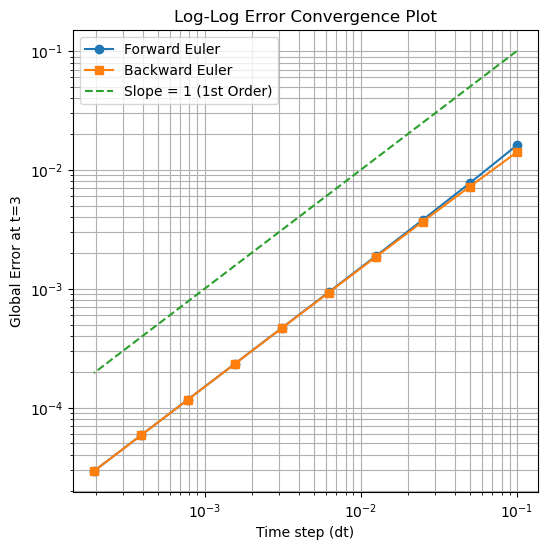

In [3]:
t_target = 3.0
exact_sol = np.exp(lmbda * t_target)
errors_f = []
errors_b = []
dts = [0.1 / (2**k) for k in range(10)]

for dt in dts:
    t, yf, yb = simulate_euler(dt, t_end=t_target)
    idx = np.argmin(np.abs(t - t_target))
    errors_f.append(np.abs(yf[idx] - exact_sol))
    errors_b.append(np.abs(yb[idx] - exact_sol))

plt.figure(figsize=(6, 6))
plt.loglog(dts, errors_f, '-o', label='Forward Euler')
plt.loglog(dts, errors_b, '-s', label='Backward Euler')
plt.loglog(dts, dts, '--', label='Slope = 1 (1st Order)')
plt.xlabel('Time step (dt)')
plt.ylabel('Global Error at t=3')
plt.legend()
plt.title('Log-Log Error Convergence Plot')
plt.grid(True, which="both")
plt.show()